In [2]:
import pandas as pd

df = pd.read_csv('/content/student-mat.csv', sep=';')

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [3]:
df.shape

(395, 33)

In [6]:
df.dtypes


,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


In [7]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [11]:
df.describe()
df.describe(include='all')
df.nunique()

,0
school,2
sex,2
age,8
address,2
famsize,2
Pstatus,2
Medu,5
Fedu,5
Mjob,5
Fjob,5


In [13]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


<Axes: xlabel='age', ylabel='Count'>

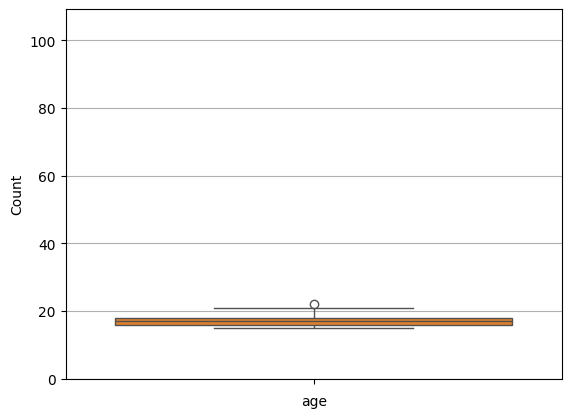

In [17]:
import seaborn as sns

df['age'].hist(bins=30)
sns.histplot(df['age'], kde=True)   # histogram + density curve
sns.boxplot(y=df['age'])            # shows outliers clearly

<Axes: xlabel='school', ylabel='count'>

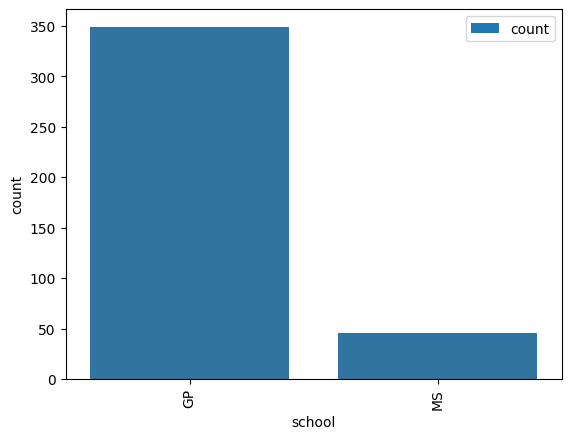

In [19]:
df['school'].value_counts().plot(kind='bar')
sns.countplot(x='school', data=df)

<Axes: >

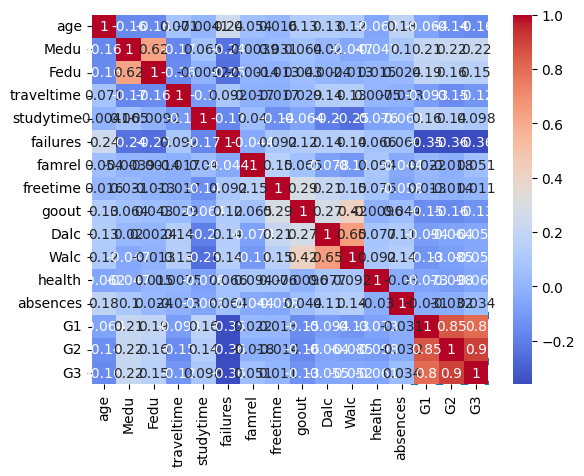

In [22]:
sns.scatterplot(x='G1', y='G3', data=df)
df[['G1','G2','G3']].corr()               # correlation matrix
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')

<Axes: xlabel='schoolsup', ylabel='absences'>

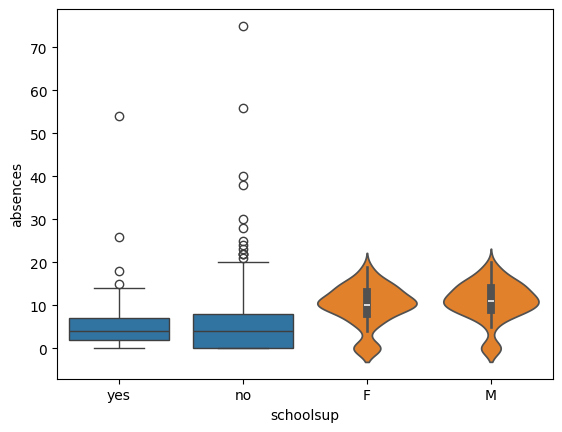

In [24]:
sns.boxplot(x='schoolsup', y='absences', data=df)
sns.violinplot(x='sex', y='G3', data=df)

<Axes: xlabel='pass', ylabel='school'>

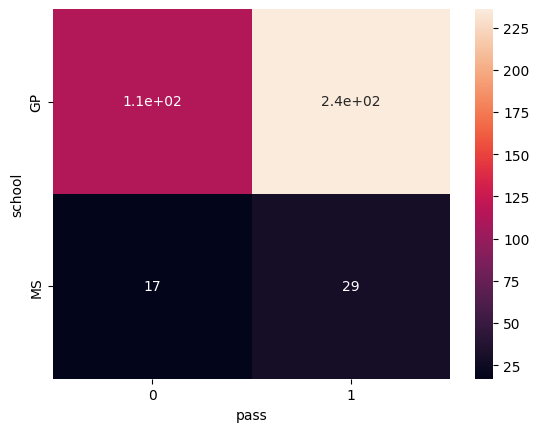

In [26]:
df['pass'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)
pd.crosstab(df['school'], df['pass'])
sns.heatmap(pd.crosstab(df['school'], df['pass']), annot=True)

<Axes: >

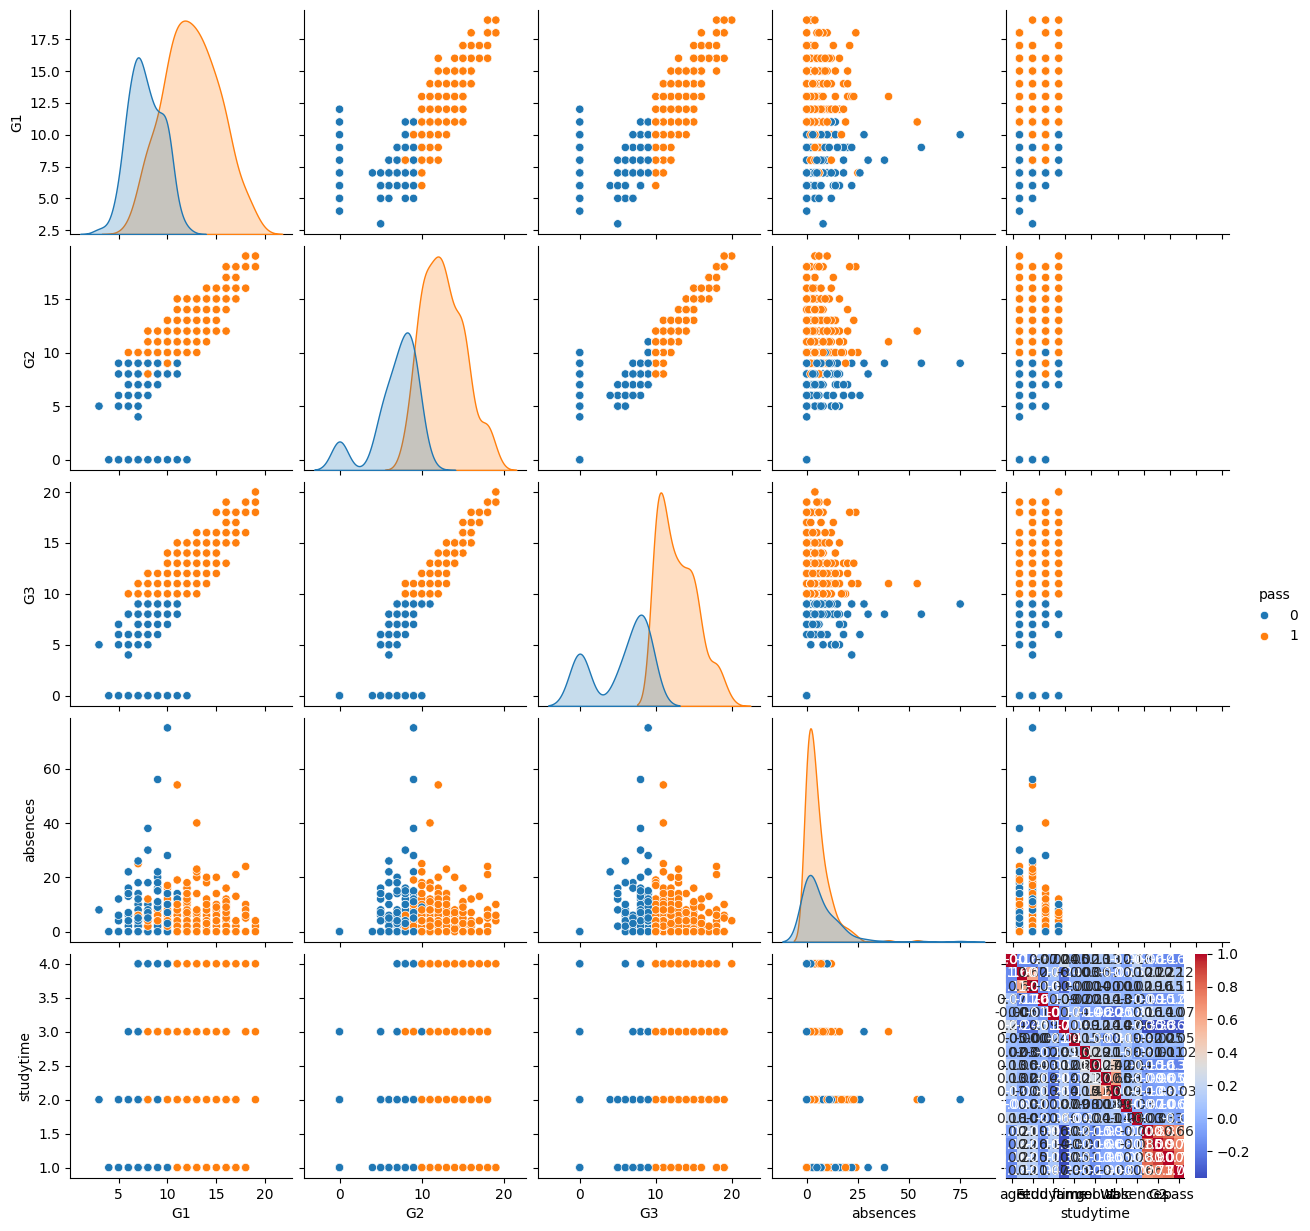

In [29]:
sns.pairplot(df[['G1','G2','G3','absences','studytime', 'pass']], hue='pass')
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, fmt='.2f', cmap='coolwarm')

In [32]:
# IQR method
Q1 = df['absences'].quantile(0.25)
Q3 = df['absences'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['absences'] < Q1 - 1.5*IQR) | (df['absences'] > Q3 + 1.5*IQR)]

# Z-score method
from scipy import stats
z_scores = stats.zscore(df['absences'])
outliers = df[abs(z_scores) > 3]

<Axes: xlabel='pass', ylabel='count'>

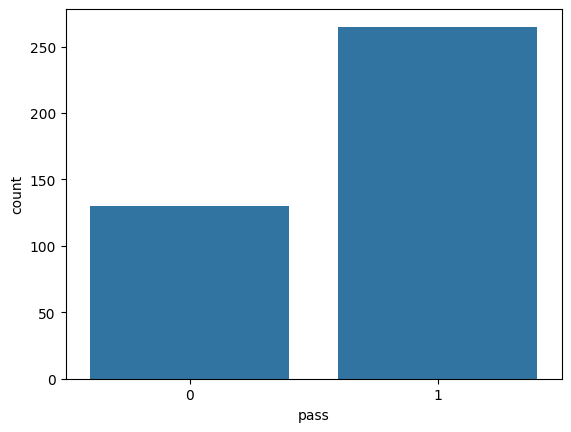

In [33]:
df['pass'].value_counts()
df['pass'].value_counts(normalize=True) * 100   # percentage
sns.countplot(x='pass', data=df)

In [35]:
df.select_dtypes(include=['number']).corr()['pass'].sort_values(ascending=False)

,pass
pass,1.000000
G3,0.770042
G2,0.725407
G1,0.664979
Medu,0.115396
Fedu,0.108057
studytime,0.074613
famrel,0.046683
freetime,-0.018321
Walc,-0.029957


In [36]:
df.duplicated().sum()

np.int64(0)